In [1]:
import pandas as pd
import numpy as np
import paramiko
from scp import SCPClient
from isd import Batch
from meteostat import Stations, Hourly
from timezonefinder import TimezoneFinder
from datetime import datetime, timedelta, date
import pytz
import os
import math



Import Dru's file



In [2]:
import pandas as pd

# Function to read an EPW file and return a DataFrame
def read_epw(file_path):
    # Read the EPW file skipping the header rows (metadata)
    header_lines = 8  # EPW files usually have a header of 8 lines
    epw_data = pd.read_csv(file_path, skiprows=header_lines, header=None)

    # Define column names for EPW based on EnergyPlus standards
    column_names = [
        "Year", "Month", "Day", "Hour", "Minute",
        "Data Source and Uncertainty Flags", "Dry Bulb Temperature (°C)", "Dew Point Temperature (°C)", 
        "Relative Humidity (%)", "Atmospheric Station Pressure (Pa)", 
        "Extraterrestrial Horizontal Radiation (Wh/m²)", "Extraterrestrial Direct Normal Radiation (Wh/m²)",
        "Horizontal Infrared Radiation Intensity (Wh/m²)", "Global Horizontal Radiation (Wh/m²)",
        "Direct Normal Radiation (Wh/m²)", "Diffuse Horizontal Radiation (Wh/m²)", 
        "Global Horizontal Illuminance (lux)", "Direct Normal Illuminance (lux)",
        "Diffuse Horizontal Illuminance (lux)", "Zenith Luminance (cd/m²)", 
        "Wind Direction (degrees)", "Wind Speed (m/s)", "Total Sky Cover (tenths)", 
        "Opaque Sky Cover (tenths)", "Visibility (km)", "Ceiling Height (m)",
        "Present Weather Observation", "Present Weather Codes", 
        "Precipitable Water (mm)", "Aerosol Optical Depth (thousandths)", 
        "Snow Depth (cm)", "Days Since Last Snowfall", "Albedo", 
        "Liquid Precipitation Depth (mm)", "Liquid Precipitation Quantity (hr)"
    ]
    epw_data.columns = column_names

    # Create a datetime column from Year, Month, Day, and Hour
    epw_data['Datetime'] = pd.to_datetime(
        epw_data[['Year', 'Month', 'Day', 'Hour']].assign(
            Minute=epw_data['Minute'] // 60  # EPW minute is fractional (e.g., 30.0 for 30 minutes past the hour)
        )
    )
    
    # Drop redundant date columns if desired
    epw_data = epw_data.drop(columns=["Year", "Month", "Day", "Hour", "Minute"])
    
    # Set datetime as the index
    epw_data.set_index('Datetime', inplace=True)
    
    return epw_data

# Usage
epw_df = read_epw('USA_CO_Denver.Intl.AP.725650_TMYx.epw')

epw_df

,Data Source and Uncertainty Flags,Dry Bulb Temperature (°C),Dew Point Temperature (°C),Relative Humidity (%),Atmospheric Station Pressure (Pa),Extraterrestrial Horizontal Radiation (Wh/m²),Extraterrestrial Direct Normal Radiation (Wh/m²),Horizontal Infrared Radiation Intensity (Wh/m²),Global Horizontal Radiation (Wh/m²),Direct Normal Radiation (Wh/m²),...,Ceiling Height (m),Present Weather Observation,Present Weather Codes,Precipitable Water (mm),Aerosol Optical Depth (thousandths),Snow Depth (cm),Days Since Last Snowfall,Albedo,Liquid Precipitation Depth (mm),Liquid Precipitation Quantity (hr)
Datetime,,,,,,,,,,,,,,,,,,,,,
2002-01-01 01:00:00,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9?9?9*9*9?9*9,-7.0,-8.0,92,82321,0,0,255,0,0,...,1290,0,999099999,4,0.085,1,88,0.24,0.0,0.0
2002-01-01 02:00:00,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9?9?9*9*9?9*9,-8.0,-11.1,78,82258,0,0,257,0,0,...,660,0,999099999,3,0.085,1,88,0.25,0.1,0.0
2002-01-01 03:00:00,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9?9?9*9*9?9*9,-7.2,-8.3,91,83173,0,0,274,0,0,...,945,0,999099999,4,0.085,1,88,0.25,0.2,0.0
2002-01-01 04:00:00,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9?9?9*9*9?9*9,-7.2,-8.9,86,83222,0,0,271,0,0,...,1280,0,999099999,4,0.085,2,88,0.26,0.2,0.0
2002-01-01 05:00:00,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9?9?9*9*9?9*9,-8.0,-8.0,100,82258,0,0,272,0,0,...,690,0,999099999,4,0.085,2,88,0.27,0.2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2003-12-31 20:00:00,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9*9?9*9*9?9*9,3.5,-8.9,40,82634,0,0,241,0,0,...,6706,9,999999999,4,0.085,0,88,0.18,0.0,0.0
2003-12-31 21:00:00,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9*9?9*9*9?9*9,0.3,-10.4,44,82620,0,0,235,0,0,...,6706,9,999999999,3,0.085,0,88,0.18,0.0,0.0
2003-12-31 22:00:00,?9?9?9?9E0?9?9?9?9?9?9?9?9?9?9?9*9?9*9*9?9*9,0.2,-10.6,44,82625,0,0,224,0,0,...,6706,9,999999999,3,0.085,0,88,0.18,0.0,0.0


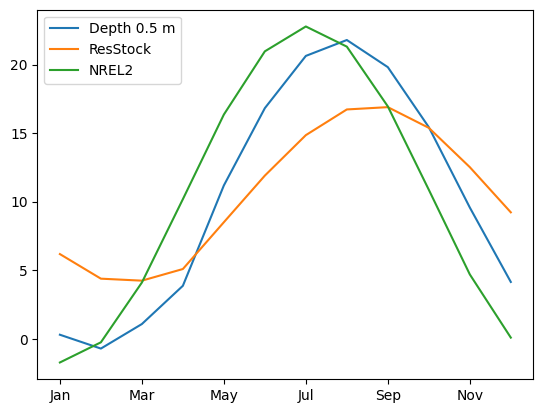

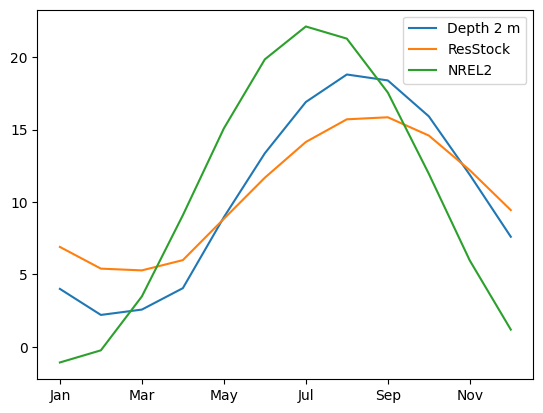

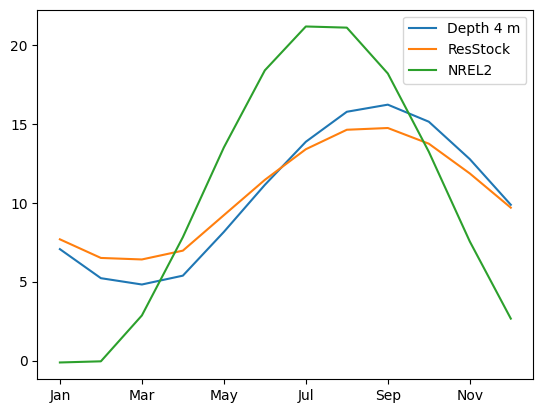

In [3]:
def convert(value, from_unit, to_unit):
    if from_unit == "yr" and to_unit == "hr":
        return value * 365.25 * 24  # 1 year = 365.25 days * 24 hours
    elif from_unit == "C" and to_unit == "R":
        return (value + 273.15) * 9/5  # Celsius to Rankine
    elif from_unit == "R" and to_unit == "C":
        return (value - 491.67) * 5/9  # Rankine to Celsius
    elif from_unit == "C" and to_unit == "F":
        return value * 9/5 + 32  # Celsius to Fahrenheit
    elif from_unit == "F" and to_unit == "C":
        return (value - 32) * 5/9  # Fahrenheit to Celsius
    elif from_unit == "R" and to_unit == "F":
        return value - 459.67  # Rankine to Fahrenheit
    else:
        raise ValueError(f"Unsupported conversion from {from_unit} to {to_unit}")
    if from_unit == "yr" and to_unit == "hr":
        return value * 365.25 * 24  # 1 year = 365.25 days * 24 hours
    elif from_unit == "C" and to_unit == "R":
        return (value + 273.15) * 9/5  # Celsius to Rankine
    elif from_unit == "R" and to_unit == "C":
        return (value - 491.67) * 5/9  # Rankine to Celsius
    elif from_unit == "C" and to_unit == "F":
        return value * 9/5 + 32  # Celsius to Fahrenheit
    elif from_unit == "F" and to_unit == "C":
        return (value - 32) * 5/9  # Fahrenheit to Celsius
    else:
        raise ValueError(f"Unsupported conversion from {from_unit} to {to_unit}")

def calc_shallow_ground_temperatures_from_df(df, depth):
    amon = [15.0, 46.0, 74.0, 95.0, 135.0, 166.0, 196.0, 227.0, 258.0, 288.0, 319.0, 349.0]
    po = 0.6
    dif = 0.025
    p = convert(1.0, 'yr', 'hr')

    # Calculate monthly and annual averages in Celsius
    monthly_avg_drybulbs_c = df.groupby(df.index.month)['Dry Bulb Temperature (°C)'].mean()
    annual_avg_drybulb_c = df['Dry Bulb Temperature (°C)'].mean()

    # Convert average temperatures to Rankine for decay calculations
    monthly_avg_drybulbs_r = monthly_avg_drybulbs_c.apply(lambda x: convert(x, 'C', 'R'))
    annual_avg_drybulb_r = convert(annual_avg_drybulb_c, 'C', 'R')

    # Beta and other constants
    beta = math.sqrt(math.pi / (p * dif)) * 10.0
    x = math.exp(-beta)
    s = math.sin(beta)
    c = math.cos(beta)
    y = (x**2 - 2.0 * x * c + 1.0) / (2.0 * beta**2.0)
    depth_factor = math.exp(-depth * math.sqrt(math.pi / (p * dif)))

    gm = math.sqrt(y) * depth_factor
    z = (1.0 - x * (c + s)) / (1.0 - x * (c - s))
    phi = math.atan(z)
    bo = (monthly_avg_drybulbs_r.max() - monthly_avg_drybulbs_r.min()) * 0.5

    # Calculate shallow ground temperatures
    shallow_ground_monthly_temps_r = []
    for i in range(12):  # Loop through 12 months
        theta = amon[i] * 24.0
        temp = annual_avg_drybulb_r - bo * math.cos(2.0 * math.pi / p * theta - po - phi) * gm
        shallow_ground_monthly_temps_r.append(temp)

    # Convert results to Celsius and Fahrenheit
    shallow_ground_monthly_temps_c = [convert(temp, 'R', 'C') for temp in shallow_ground_monthly_temps_r]
    shallow_ground_monthly_temps_f = [convert(temp, 'C', 'F') for temp in shallow_ground_monthly_temps_c]

    # Create output DataFrame
    result = pd.DataFrame({
        'Month': range(1, 13),
        'Shallow Ground Temperature (°C)': shallow_ground_monthly_temps_c,
        'Shallow Ground Temperature (°F)': shallow_ground_monthly_temps_f
    })
    result['Annual Shallow Ground Temperature (°C)'] = convert(annual_avg_drybulb_r, 'R', 'C')
    result['Annual Shallow Ground Temperature (°F)'] = convert(annual_avg_drybulb_r, 'R', 'F')

    return result

def calculate_monthly_average_ground_temp_from_data(depth, hourly_df):
    """
    Calculate monthly average ground temperatures as a function of depth using the Kusuda and Achenbach model,
    with parameters derived from an hourly dataset.

    Parameters:
        depth (float): Depth below the ground surface (in meters).
        hourly_df (pd.DataFrame): DataFrame containing 8760 hourly data with column 'Dry Bulb Temperature (°C)'.
        thermal_diffusivity (float): Ground thermal diffusivity (m²/s).

    Returns:
        tuple:
            - list[float]: Monthly average ground temperatures (°C).
            - dict: Derived parameters including ave_ground_temp, ave_ground_temp_amplitude, and phase_shift_days.
    """
    # Constants
    secs_in_day = 24 * 3600
    days_in_year = 365
    secs_in_year = days_in_year * secs_in_day
    avg_days_in_month = 30

    thermal_diffusivity = 0.0001  # Thermal diffusivity in m²/s


    # Derive ave_ground_temp, ave_ground_temp_amplitude, and phase_shift_days
    hourly_df['Month'] = hourly_df.index.month
    monthly_avg_temps = hourly_df.groupby('Month')['Dry Bulb Temperature (°C)'].mean()

    ave_ground_temp = monthly_avg_temps.mean()  # Annual average temperature
    max_temp = monthly_avg_temps.max()
    min_temp = monthly_avg_temps.min()
    ave_ground_temp_amplitude = (max_temp - min_temp) / 2.0  # Amplitude of fluctuation

    # Find the month of minimum temperature for phase shift
    month_of_min_temp = monthly_avg_temps.idxmin()
    phase_shift_days = (month_of_min_temp - 1) * avg_days_in_month + avg_days_in_month / 2

    # Decay factor for depth
    decay_factor = -depth * math.sqrt(math.pi / (secs_in_year * thermal_diffusivity))

    # Calculate monthly ground temperatures
    monthly_ground_temps = []
    for month in range(1, 13):
        # Approximate the middle of each month in seconds
        month_middle_secs = (days_in_year / 12) * secs_in_day * (month - 0.5)

        # Time-based cosine term
        term2 = (2 * math.pi / secs_in_year) * (
            month_middle_secs - phase_shift_days * secs_in_day - depth * math.sqrt(secs_in_year / (math.pi * thermal_diffusivity))
        )

        # Calculate temperature
        temp = ave_ground_temp - ave_ground_temp_amplitude * math.exp(decay_factor) * math.cos(term2)
        monthly_ground_temps.append(temp)

    # Return monthly ground temperatures and derived parameters
    derived_params = {
        "ave_ground_temp": ave_ground_temp,
        "ave_ground_temp_amplitude": ave_ground_temp_amplitude,
        "phase_shift_days": phase_shift_days,
    }
    return monthly_ground_temps

# Data
data = {
    "Jan": [0.29, 4.00, 7.06],
    "Feb": [-0.72, 2.20, 5.22],
    "Mar": [1.07, 2.57, 4.82],
    "Apr": [3.86, 4.05, 5.38],
    "May": [11.18, 8.95, 8.15],
    "Jun": [16.82, 13.37, 11.13],
    "Jul": [20.63, 16.91, 13.86],
    "Aug": [21.79, 18.81, 15.76],
    "Sep": [19.81, 18.40, 16.21],
    "Oct": [15.43, 15.92, 15.13],
    "Nov": [9.57, 11.88, 12.76],
    "Dec": [4.14, 7.60, 9.87],
}

# Index representing depths
depths = ["Depth 0.5 m", "Depth 2 m", "Depth 4 m"]

# Create the DataFrame
ground_temp_df = pd.DataFrame(data, index=depths).transpose()

# depth = 0.5

for depth in [0.5, 2, 4]:
    resstock_t = calc_shallow_ground_temperatures_from_df(epw_df, depth)['Shallow Ground Temperature (°C)']
    openstudio_t = calculate_monthly_average_ground_temp_from_data(depth, epw_df)
    ground_temp_df2 = (ground_temp_df[f"Depth {depth} m"]).to_frame()
    ground_temp_df2['ResStock'] = list(resstock_t)
    ground_temp_df2['NREL2'] = list(openstudio_t)


    ground_temp_df2.plot()


In [5]:
import math
import pandas as pd

def calc_combined_ground_temperatures(df):
    """
    Calculate shallow ground temperatures for multiple depths using the Kusuda and Achenbach model
    and format results as a single EPW GROUND TEMPERATURES line.
    
    Parameters:
        df (pd.DataFrame): DataFrame with hourly temperatures in column 'Dry Bulb Temperature (°C)'.
        depths (list of float): List of depths below the ground surface in meters.
        
    Returns:
        str: Combined GROUND TEMPERATURES line in EPW file format for all depths.
    """
    depths = [0.5, 2, 4]

    # Conversion utility
    def convert(value, from_unit, to_unit):
        if from_unit == "yr" and to_unit == "hr":
            return value * 365.25 * 24  # 1 year = 365.25 days * 24 hours
        elif from_unit == "C" and to_unit == "R":
            return (value + 273.15) * 9 / 5  # Celsius to Rankine
        elif from_unit == "R" and to_unit == "C":
            return (value - 491.67) * 5 / 9  # Rankine to Celsius
        elif from_unit == "C" and to_unit == "F":
            return value * 9 / 5 + 32  # Celsius to Fahrenheit
        elif from_unit == "F" and to_unit == "C":
            return (value - 32) * 5 / 9  # Fahrenheit to Celsius
        elif from_unit == "R" and to_unit == "F":
            return value - 459.67  # Rankine to Fahrenheit
        else:
            raise ValueError(f"Unsupported conversion from {from_unit} to {to_unit}")

    # Constants
    amon = [15.0, 46.0, 74.0, 95.0, 135.0, 166.0, 196.0, 227.0, 258.0, 288.0, 319.0, 349.0]  # Approx. mid-month days
    po = 0.6  # Phase offset
    dif = 0.025  # Thermal diffusivity (m²/hr)
    p = convert(1.0, 'yr', 'hr')  # Convert 1 year to hours

    # Calculate monthly and annual averages in Celsius
    monthly_avg_drybulbs_c = df.groupby(df.index.month)['Dry Bulb Temperature (°C)'].mean()
    annual_avg_drybulb_c = df['Dry Bulb Temperature (°C)'].mean()

    # Convert average temperatures to Rankine for decay calculations
    monthly_avg_drybulbs_r = monthly_avg_drybulbs_c.apply(lambda x: convert(x, 'C', 'R'))
    annual_avg_drybulb_r = convert(annual_avg_drybulb_c, 'C', 'R')

    # Prepare the combined GROUND TEMPERATURES line
    combined_ground_temperatures = ["GROUND TEMPERATURES", str(len(depths))]  # Start with header and number of depths

    for depth in depths:
        # Kusuda and Achenbach parameters
        beta = math.sqrt(math.pi / (p * dif)) * 10.0
        x = math.exp(-beta)
        s = math.sin(beta)
        c = math.cos(beta)
        y = (x**2 - 2.0 * x * c + 1.0) / (2.0 * beta**2.0)
        depth_factor = math.exp(-depth * math.sqrt(math.pi / (p * dif)))

        gm = math.sqrt(y) * depth_factor
        z = (1.0 - x * (c + s)) / (1.0 - x * (c - s))
        phi = math.atan(z)
        bo = (monthly_avg_drybulbs_r.max() - monthly_avg_drybulbs_r.min()) * 0.5

        # Calculate shallow ground temperatures
        shallow_ground_monthly_temps_r = []
        for i in range(12):  # Loop through 12 months
            theta = amon[i] * 24.0  # Day of the year to hours
            temp = annual_avg_drybulb_r - bo * math.cos(2.0 * math.pi / p * theta - po - phi) * gm
            shallow_ground_monthly_temps_r.append(temp)

        # Convert results to Celsius
        shallow_ground_monthly_temps_c = [convert(temp, 'R', 'C') for temp in shallow_ground_monthly_temps_r]

        # Add the depth, empty spaces, and monthly temperatures to the combined line
        combined_ground_temperatures.append(f"{depth:.1f}")
        combined_ground_temperatures.extend([""] * 3)  # Add three empty spaces
        combined_ground_temperatures.extend([f"{temp:.2f}" for temp in shallow_ground_monthly_temps_c])

    # Return the formatted line as a single string
    return ",".join(combined_ground_temperatures)

ground_temp_line = calc_combined_ground_temperatures(epw_df)
ground_temp_line



'GROUND TEMPERATURES,3,0.5,,,,6.17,4.38,4.23,5.08,8.50,11.90,14.85,16.72,16.89,15.38,12.52,9.22,2.0,,,,6.90,5.40,5.28,5.99,8.84,11.68,14.15,15.71,15.85,14.59,12.20,9.44,4.0,,,,7.68,6.50,6.41,6.96,9.21,11.45,13.39,14.62,14.73,13.74,11.85,9.68'